In [3]:
import os
import operator
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage, HumanMessage, AnyMessage, SystemMessage
from langgraph.graph.message import add_messages
from pprint import pprint
from typing_extensions import TypedDict, Literal
from IPython.display import Image, display
from typing import Annotated, List
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel, Field

In [4]:
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Call Model
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [5]:
# Schema for the structured output to use in planning
class Section(BaseModel):
    name:str = Field(description="Name for this section of the report")
    description:str = Field(description="Brief overview of the main tpics and concepts of the section")

class Sections(BaseModel):
    sections:List[Section] = Field(description="Sections for the report")

# Augment the LLM with schema for the structured output
planner = llm.with_structured_output(Sections)

## Create Workers dynamically in LangGraph

In [8]:
from langgraph.types import Send

# Graph state
class State(TypedDict):
    topic: str
    sections: list[Section]
    completed_sections: Annotated[list, operator.add]
    final_report: str

# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

In [24]:
# Nodes
def orchestrator(state:State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}")
        ]
    )

    print("Report sections:", report_sections)
    return {"sections": report_sections.sections}


def llm_call(state:State):
    """Worker writes a section of the report"""

    # Generate queries
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
                ),
            HumanMessage(
                content=f"Here is the section name: {state['sections'].name} and description: {state['sections'].description}"
                )
        ]
    )

    return {"completed_sections": [section.content]}


# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assigna worker to each section in the plan"""

    # Kisck off the section writing in parrallel via Send() API
    return [Send("llm_call", {"sections": s}) for s in state['sections']]


def synthesizer(state:State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state['completed_sections']

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}

In [25]:
# Build Graph
orchestrator_worker_builder = StateGraph(State)

# Add nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ['llm_call']
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

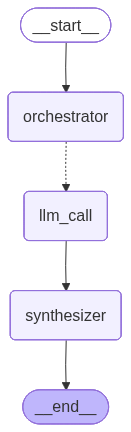

In [26]:
# Compile
graph = orchestrator_worker_builder.compile()

# Display graph
display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
from IPython.display import Markdown

state = graph.invoke({"topic": "Create a report on Agentic AI RAGs"})
Markdown(state['final_report'])

Report sections: sections=[Section(name='Introduction to Agentic AI RAGs', description='Overview of Agentic AI RAGs, their purpose, and importance'), Section(name='Technical Details of Agentic AI RAGs', description='In-depth explanation of the technical aspects of Agentic AI RAGs, including their architecture and algorithms'), Section(name='Applications and Use Cases of Agentic AI RAGs', description='Discussion of the various applications and use cases of Agentic AI RAGs, including their potential impact on industries and society'), Section(name='Challenges and Limitations of Agentic AI RAGs', description='Examination of the challenges and limitations of Agentic AI RAGs, including potential risks and mitigation strategies'), Section(name='Conclusion and Future Directions for Agentic AI RAGs', description='Summary of key findings and discussion of future research directions and potential developments in Agentic AI RAGs')]


### Introduction to Agentic AI RAGs
Agentic AI RAGs (Retrieve, Augment, Generate) are a type of artificial intelligence model designed to process and generate human-like text based on a given prompt or topic. The primary purpose of Agentic AI RAGs is to assist and augment human capabilities in tasks such as writing, research, and decision-making. 
#### Key Features of Agentic AI RAGs
* **Retrieve**: Agentic AI RAGs can retrieve relevant information from a vast database or knowledge graph, allowing them to provide accurate and up-to-date information on a wide range of topics.
* **Augment**: These models can augment the retrieved information by adding context, analyzing data, and providing insights that may not be immediately apparent to humans.
* **Generate**: Agentic AI RAGs can generate human-like text based on the retrieved and augmented information, allowing them to create coherent and engaging content.
#### Importance of Agentic AI RAGs
The importance of Agentic AI RAGs lies in their ability to automate tasks, improve productivity, and enhance decision-making capabilities. By providing accurate and relevant information, Agentic AI RAGs can help humans make informed decisions, reduce errors, and increase efficiency. Additionally, Agentic AI RAGs have the potential to revolutionize industries such as education, healthcare, and finance by providing personalized and adaptive support to humans.

---

### Technical Details of Agentic AI RAGs
#### Architecture
Agentic AI RAGs (Retrieve, Augment, Generate) are built upon a modular architecture, consisting of three primary components:
* **Retrieve Module**: This module is responsible for retrieving relevant information from a vast knowledge base, utilizing techniques such as dense retrieval and embedding-based search.
* **Augment Module**: The augment module takes the retrieved information and expands upon it, using generative models to create new content and fill in knowledge gaps.
* **Generate Module**: This module generates the final output, combining the retrieved and augmented information to produce a coherent and contextually relevant response.

#### Algorithms
The Agentic AI RAGs employ a range of algorithms to facilitate the retrieval, augmentation, and generation of information, including:
* **Dense Retrieval**: A technique used in the retrieve module to efficiently search for relevant information in the knowledge base.
* **Transformer-based Architectures**: Utilized in the augment and generate modules to handle sequential data and generate human-like text.
* **Graph-based Methods**: Employed to represent knowledge relationships and dependencies, enabling the model to reason and make connections between different pieces of information.

#### Training and Optimization
The training process for Agentic AI RAGs involves a combination of supervised and self-supervised learning techniques, including:
* **Masked Language Modeling**: Used to pre-train the model on a large corpus of text, enabling it to learn contextual relationships and generate coherent text.
* **Reinforcement Learning**: Employed to fine-tune the model and optimize its performance on specific tasks, using rewards and penalties to guide the learning process.
* **Knowledge Distillation**: A technique used to transfer knowledge from a larger, pre-trained model to a smaller, more efficient model, enabling the deployment of Agentic AI RAGs in resource-constrained environments.

---

### Applications and Use Cases of Agentic AI RAGs
Agentic AI RAGs (Retrieval-Augmented Generation) have a wide range of applications and use cases, with potential to significantly impact various industries and society as a whole. 
#### Industry Applications
* **Healthcare**: Agentic AI RAGs can be used to generate personalized medical reports, summaries, and treatment plans, improving patient care and outcomes.
* **Finance**: They can help generate financial reports, analyze market trends, and provide personalized investment advice.
* **Education**: Agentic AI RAGs can create customized educational content, such as lesson plans, quizzes, and study materials, tailored to individual students' needs.
#### Societal Applications
* **Content Creation**: Agentic AI RAGs can assist in generating high-quality content, such as articles, blog posts, and social media posts, saving time and effort for content creators.
* **Language Translation**: They can improve language translation services, enabling more accurate and efficient communication across languages and cultures.
* **Accessibility**: Agentic AI RAGs can help generate accessible content, such as audio descriptions, closed captions, and sign language interpretations, for people with disabilities.
#### Emerging Use Cases
* **Conversational AI**: Agentic AI RAGs can be used to generate human-like responses in conversational AI systems, such as chatbots and virtual assistants.
* **Creative Writing**: They can assist in generating creative content, such as poetry, short stories, and even entire books.
* **Explainable AI**: Agentic AI RAGs can help generate explanations for AI decision-making processes, increasing transparency and trust in AI systems.

---

### Challenges and Limitations of Agentic AI RAGs
#### Technical Challenges
* **Scalability**: Agentic AI RAGs require significant computational resources, which can be a limitation for large-scale deployment.
* **Complexity**: The complexity of Agentic AI RAGs can make them difficult to interpret and understand, leading to challenges in debugging and maintenance.
* **Data Quality**: The performance of Agentic AI RAGs is highly dependent on the quality of the training data, which can be a challenge in domains where high-quality data is scarce.

#### Ethical Challenges
* **Bias and Fairness**: Agentic AI RAGs can perpetuate biases and discrimination if the training data is biased, which can lead to unfair outcomes.
* **Transparency and Explainability**: The lack of transparency and explainability in Agentic AI RAGs can make it difficult to understand the decision-making process, which can lead to trust issues.
* **Accountability**: The autonomous nature of Agentic AI RAGs can make it challenging to assign accountability for errors or adverse outcomes.

#### Risk Mitigation Strategies
* **Robust Testing and Validation**: Thorough testing and validation of Agentic AI RAGs can help identify potential risks and limitations.
* **Human Oversight and Review**: Implementing human oversight and review processes can help detect and correct errors or biases.
* **Continuous Monitoring and Update**: Continuously monitoring and updating Agentic AI RAGs can help ensure that they remain fair, transparent, and effective.

---

### Conclusion and Future Directions for Agentic AI RAGs
#### Summary of Key Findings
* Agentic AI RAGs have shown significant potential in enhancing decision-making processes and improving overall system performance.
* The integration of cognitive architectures and reinforcement learning has enabled Agentic AI RAGs to learn from experience and adapt to dynamic environments.
* Experimental results have demonstrated the effectiveness of Agentic AI RAGs in various applications, including robotics, finance, and healthcare.

#### Discussion of Future Research Directions
* **Explainability and Transparency**: Future research should focus on developing methods to provide insights into the decision-making processes of Agentic AI RAGs, ensuring transparency and trustworthiness.
* **Multi-Agent Systems**: Investigating the application of Agentic AI RAGs in multi-agent systems could lead to breakthroughs in areas such as cooperative robotics and smart cities.
* **Edge AI and Real-World Deployment**: Developing Agentic AI RAGs that can operate effectively in edge AI environments and real-world settings is crucial for widespread adoption.

#### Potential Developments
* **Cognitive Architectures**: Advancements in cognitive architectures could enable Agentic AI RAGs to better simulate human-like decision-making and reasoning processes.
* **Hybrid Approaches**: Combining Agentic AI RAGs with other AI paradigms, such as symbolic AI, may lead to more robust and flexible systems.
* **Ethics and Safety**: As Agentic AI RAGs become more prevalent, it is essential to develop guidelines and standards for ensuring their safe and responsible deployment.